# Digitizer Reconstruction Analysis

Dieses Notebook analysiert die Evaluations-Outputs:
- `test_results_...json` (aggregierte Kennzahlen)
- `test_details_...json` (Details pro Record, Variante, Lead)


In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


In [3]:
# Pfade anpassen falls noetig
RESULTS_PATH = Path('/workspace/postprocessing/results/test_results_norm_ref_w2000_digitizer_all.json')
DETAILS_PATH = Path('/workspace/postprocessing/results/test_details_norm_ref_w2000_digitizer_all.json')

summary = json.loads(RESULTS_PATH.read_text())
details = json.loads(DETAILS_PATH.read_text())

print('Loaded:')
print('-', RESULTS_PATH)
print('-', DETAILS_PATH)


Loaded:
- /workspace/postprocessing/results/test_results_norm_ref_w2000_digitizer_all.json
- /workspace/postprocessing/results/test_details_norm_ref_w2000_digitizer_all.json


In [4]:
# 1) Quick overview
overview_keys = [
    'overall_mae', 'overall_rmse',
    'missing_snr_db_digitizer', 'missing_snr_db_recon', 'missing_snr_db_improvement',
    'global_snr_db_digitizer', 'global_snr_db_recon', 'global_snr_db_improvement',
    'present_snr_db_digitizer', 'present_snr_db_recon', 'present_snr_db_improvement',
]
overview = {k: summary.get(k, np.nan) for k in overview_keys}
pd.DataFrame([overview]).T.rename(columns={0: 'value'})


,value
overall_mae,0.098725
overall_rmse,0.125864
missing_snr_db_digitizer,1.717486
missing_snr_db_recon,1.551173
missing_snr_db_improvement,-0.166313
global_snr_db_digitizer,1.482769
global_snr_db_recon,1.505267
global_snr_db_improvement,0.022498
present_snr_db_digitizer,1.523375
present_snr_db_recon,1.523375


,variant,mae,rmse,snr_missing,snr_global,snr_global_digitizer,snr_global_delta
0,0001,0.077731,0.096960,3.290611,11.009788,10.634804,0.374984
1,0003,0.143779,0.180534,1.616160,-0.203061,-0.137713,-0.065348
2,0004,0.108581,0.138544,1.813667,0.199833,0.227294,-0.027461
3,0005,0.083731,0.103309,0.886950,-0.742572,-0.757677,0.015105
4,0006,0.098452,0.139961,0.970854,2.283872,2.341003,-0.057131
5,0009,0.078915,0.095576,2.301504,1.835686,1.807194,0.028491
6,0010,0.085885,0.104300,1.559941,0.397771,0.391034,0.006737
7,0011,0.097509,0.123180,0.846629,-0.574706,-0.547392,-0.027314
8,0012,0.113941,0.150414,0.331053,-0.659209,-0.613628,-0.045581


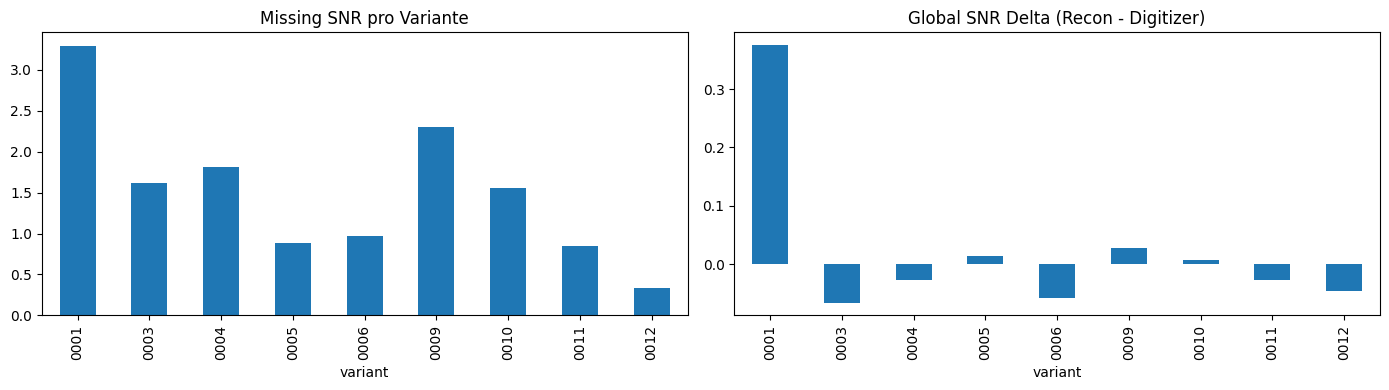

In [5]:
# 2) Per-variant analysis
var_df = pd.DataFrame(details.get('per_variant', {})).T.reset_index().rename(columns={'index': 'variant'})
if not var_df.empty and 'snr_global_digitizer' in var_df.columns:
    var_df['snr_global_delta'] = var_df['snr_global'] - var_df['snr_global_digitizer']

display(var_df.sort_values('variant'))

if not var_df.empty:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    var_df.sort_values('variant').plot(x='variant', y='snr_missing', kind='bar', ax=ax[0], legend=False, title='Missing SNR pro Variante')
    if 'snr_global_delta' in var_df.columns:
        var_df.sort_values('variant').plot(x='variant', y='snr_global_delta', kind='bar', ax=ax[1], legend=False, title='Global SNR Delta (Recon - Digitizer)')
    else:
        var_df.sort_values('variant').plot(x='variant', y='snr_global', kind='bar', ax=ax[1], legend=False, title='Global SNR pro Variante')
    plt.tight_layout()
    plt.show()


variant,0001,0003,0004,0005,0006,0009,0010,0011,0012
lead,,,,,,,,,
I,0.017334,0.007911,0.009535,0.016522,0.015571,0.012905,0.014391,0.014399,0.015264
II,0.008540,0.011958,0.013445,0.011839,0.060913,0.011187,0.006127,0.009233,0.014936
III,0.017063,0.009376,0.011941,0.016961,0.027252,0.015080,0.010923,0.011874,0.012453
V1,0.026081,0.017356,0.018521,0.018518,0.023973,0.021036,0.021365,0.017468,0.019728
V2,0.044114,0.036115,0.038223,0.035236,0.056563,0.032770,0.039337,0.030061,0.049307
V3,0.044158,0.060531,0.065414,0.047378,0.076504,0.043742,0.043468,0.058503,0.068486
V4,0.021372,0.034464,0.034286,0.031624,0.034855,0.021748,0.022368,0.032175,0.045802
V5,0.018160,0.028424,0.030001,0.015857,0.022464,0.016783,0.019494,0.026776,0.036808
V6,0.012181,0.020333,0.020028,0.016724,0.030778,0.014307,0.012534,0.027737,0.027488


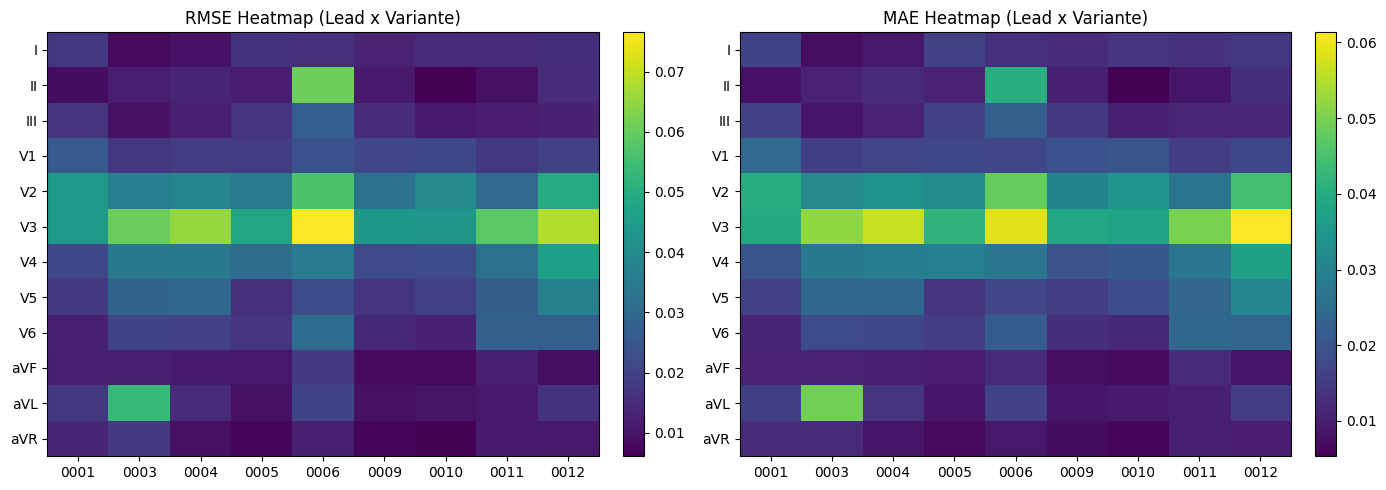

In [6]:
# 3) Per lead x variant
vlead_df = pd.DataFrame(details.get('per_variant_lead', {})).T.reset_index().rename(columns={'index': 'variant_lead'})
if not vlead_df.empty:
    parts = vlead_df['variant_lead'].str.split(':', n=1, expand=True)
    vlead_df['variant'] = parts[0]
    vlead_df['lead'] = parts[1]

    rmse_pivot = vlead_df.pivot(index='lead', columns='variant', values='rmse')
    snr_pivot = vlead_df.pivot(index='lead', columns='variant', values='mae')

    display(rmse_pivot)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    im0 = ax[0].imshow(rmse_pivot.values, aspect='auto')
    ax[0].set_title('RMSE Heatmap (Lead x Variante)')
    ax[0].set_xticks(range(len(rmse_pivot.columns)), rmse_pivot.columns)
    ax[0].set_yticks(range(len(rmse_pivot.index)), rmse_pivot.index)
    fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

    im1 = ax[1].imshow(snr_pivot.values, aspect='auto')
    ax[1].set_title('MAE Heatmap (Lead x Variante)')
    ax[1].set_xticks(range(len(snr_pivot.columns)), snr_pivot.columns)
    ax[1].set_yticks(range(len(snr_pivot.index)), snr_pivot.index)
    fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


In [7]:
# 4) Per-record: where reconstruction works / fails
rec_df = pd.DataFrame(details.get('per_record', {})).T.reset_index().rename(columns={'index': 'record_id'})
if not rec_df.empty:
    rec_df['base_id'] = rec_df['record_id'].str.split(':').str[0]

    print('Worst by missing SNR:')
    display(rec_df.sort_values('snr_missing').head(20)[['record_id', 'mae', 'rmse', 'snr_missing', 'snr_global']])

    print('Best by missing SNR:')
    display(rec_df.sort_values('snr_missing', ascending=False).head(20)[['record_id', 'mae', 'rmse', 'snr_missing', 'snr_global']])

    print('Worst by RMSE:')
    display(rec_df.sort_values('rmse', ascending=False).head(20)[['record_id', 'mae', 'rmse', 'snr_missing', 'snr_global']])


Worst by missing SNR:


,record_id,mae,rmse,snr_missing,snr_global
598,2329664655:2329664655-0006_timeseries_canonical,1.920402,2.713391,-26.148168,-28.252453
208,1539510874:1539510874-0003_timeseries_canonical,0.057296,0.060709,-25.640690,-0.862434
643,2457447088:2457447088-0006_timeseries_canonical,0.016182,0.016241,-22.959025,5.915764
318,1717124873:1717124873-0005_timeseries_canonical,0.026599,0.027319,-21.805539,-2.842956
1506,506210768:506210768-0005_timeseries_canonical,0.022021,0.022404,-16.575319,-1.694451
215,1539510874:1539510874-0012_timeseries_canonical,0.251883,0.291484,-16.108642,-5.930001
1509,506210768:506210768-0010_timeseries_canonical,0.010525,0.010879,-15.850878,-1.090460
408,1907398397:1907398397-0005_timeseries_canonical,0.022927,0.023632,-14.263665,-2.076268
437,197560770:197560770-0009_timeseries_canonical,0.127158,0.198165,-13.837743,3.730739
307,1709636457:1709636457-0003_timeseries_canonical,0.166183,0.177341,-13.758878,-3.202959


Best by missing SNR:


,record_id,mae,rmse,snr_missing,snr_global
1093,3536701389:3536701389-0006_timeseries_canonical,0.001040,0.001158,20.576574,5.028531
1518,541485763:541485763-0010_timeseries_canonical,0.008579,0.009956,17.507796,-1.319009
1005,3275080079:3275080079-0010_timeseries_canonical,0.004409,0.005963,16.834036,3.707402
1261,3863689498:3863689498-0003_timeseries_canonical,0.000543,0.000610,16.115519,0.492703
1097,3536701389:3536701389-0012_timeseries_canonical,0.002773,0.002946,15.149673,8.834139
917,314575601:314575601-0012_timeseries_canonical,0.032886,0.039020,14.541449,1.974345
1475,439738770:439738770-0012_timeseries_canonical,0.023067,0.024218,14.399064,0.015683
1105,3547378375:3547378375-0011_timeseries_canonical,0.001714,0.002135,14.314085,-1.977711
1731,880224451:880224451-0005_timeseries_canonical,0.003525,0.004316,14.242972,5.285696
634,2416193378:2416193378-0006_timeseries_canonical,0.001062,0.001216,14.096055,3.030392


Worst by RMSE:


,record_id,mae,rmse,snr_missing,snr_global
1450,4260231863:4260231863-0003_timeseries_canonical,7.654746,8.174996,-6.668561,-5.419945
598,2329664655:2329664655-0006_timeseries_canonical,1.920402,2.713391,-26.148168,-28.252453
850,290502839:290502839-0006_timeseries_canonical,1.551487,1.767616,-0.311059,4.030541
352,1783777908:1783777908-0003_timeseries_canonical,0.644954,1.714172,-4.924521,-5.137675
854,290502839:290502839-0012_timeseries_canonical,1.104892,1.593367,-5.702264,-1.191129
851,290502839:290502839-0009_timeseries_canonical,1.222209,1.546427,0.287100,5.347849
852,290502839:290502839-0010_timeseries_canonical,1.258469,1.538942,0.050936,5.438955
849,290502839:290502839-0005_timeseries_canonical,1.113193,1.374333,2.064167,2.559776
1294,3932812326:3932812326-0011_timeseries_canonical,1.160874,1.369546,-11.015545,-2.565737
1289,3932812326:3932812326-0004_timeseries_canonical,1.052444,1.194352,-5.068384,-0.566543


In [ ]:
# 5) Optional export tables for external analysis
OUT_DIR = Path('/workspace/postprocessing/results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

if 'var_df' in globals() and not var_df.empty:
    var_df.to_csv(OUT_DIR / 'analysis_per_variant.csv', index=False)
if 'vlead_df' in globals() and not vlead_df.empty:
    vlead_df.to_csv(OUT_DIR / 'analysis_per_variant_lead.csv', index=False)
if 'rec_df' in globals() and not rec_df.empty:
    rec_df.to_csv(OUT_DIR / 'analysis_per_record.csv', index=False)

print('CSV export done to', OUT_DIR)
